# Computer Vision for Microscopy

Objectives of this chapter are:
- Learn to analyze imaging data from microscopy.
- Learn how to use AI methods for microscopy at the example of image segmentation for bacteria.

## Optical Microscopy

Optical microscopes use an optical system of lenses and visible light to generate a magnified image of a sample. The maximum attainable magnification in current setups, due to physical limitations, is about 1000x. While other microscopy techniques with higher magnification exist, our use-cases typically require that the sample, e.g., a bacterial culture, can proliferate while being observed. This is currently not the case with methods like [atomic force microscopy (AFM)](https://en.wikipedia.org/wiki/Atomic_force_microscopy) and [electron microscopy](https://en.wikipedia.org/wiki/Electron_microscope).

## Image processing problems
When working with microscopy data, we usually begin with a stack of images.
Such images can be without a time-component, or snapshots of a process taken over time.

While all relevant information is within these images, we want to extract more abstract properties.
For example, we may see a bacteria moving from the left to the right, duplicating in the middle of its travel.
The abstract information that we will extract depends on the research question.
In this case, we may for example, be interested in the number and positions of all bacteria in this image.
This can then be more easily be further abstracted into, e.g., statistics about the interaction of bacteria and their single-cell
growth rates.

The main computational tasks can be grouped as follows:
- Label: Detect the presence of particular objects in an image.
- Segment: Additionally, detect the position of the objects, e.g., via a bounding box or at the pixel-level (segmentation).
- Track: Additionally, track the objects along the sequence of images.

## Image data in Python

Images are functions that assign a pixel a value.
In Python, microscopy images are usually represented as NumPy arrays of type `np.ndarray`.
The dimensionality of this array may vary, depending on the information that is stored in them.
The simplest case is a 2-dimensional array of the shape (H, W) with H being the height and W being the width of the image in pixels.

A simple gray-scale image in numpy is

In [3]:
import numpy as np

H, W = 4, 4
img = np.zeros([H, W], dtype='int64')
img[0,0] = 1.0

print(img)

[[1 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


where all pixels of the 4x4 image are black (= 0) and the top-left pixel has value 1.
Without referring to a colormap that assigns values to colors, we cannot say as which color the 1 will show up the image.

We can view this image, e.g., with `matplotlib` by calling and using the `gray` that shows tones of gray between 0 and 1.
In this colormap, the 1 will be thus white.

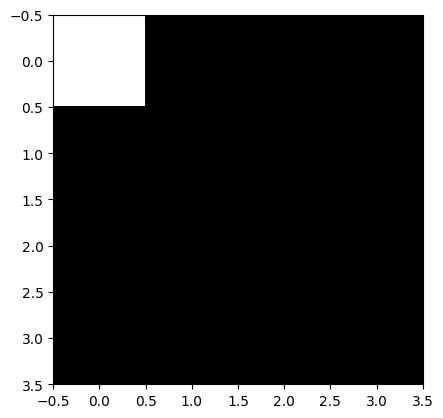

In [4]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')

With color map `jet` we would have gotten a different picture.

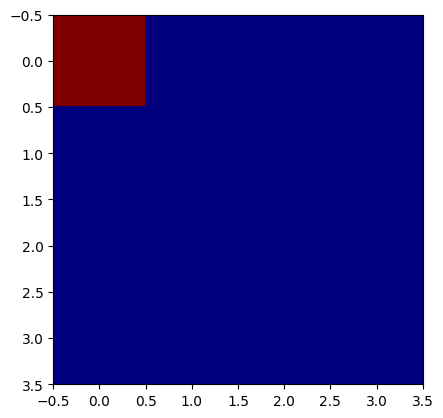

In [5]:
plt.imshow(img, cmap='jet')

### RGB vs grayscale shapes
A single-channel grayscale image typically has array-shape `(H, W)` where each pixel contains one intensity value, as we have seen before.
An RGB image adds a third dimension for color channels `(H, W, 3)` representing red, green, and blue intensities.
To unify the treatment of grayscale and RGB images, some libraries expect all images to have 3 dimensions.
In this case, a grayscale image is not a 2-D array `(H, W)`, but a 3-D array `(H, W, 1)`; the latter simply adds an explicit channel dimension, which an be created with `image[..., None]` or `np.expand_dims(image, axis=-1)`.

Let us create an RGB image with a red pixel at the top.

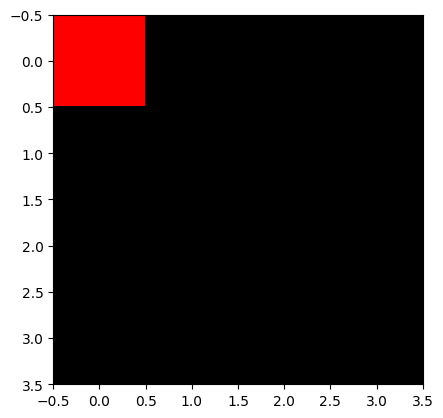

In [6]:
H, W, C = 4, 4, 3
img_rgb = np.zeros([H, W, C], dtype='int64')
img_rgb[0,0,:] = (255, 0, 0)  # (red, green, blue) from 0 to 255 -> pure red

plt.imshow(img_rgb)

### Bit depth

In the previous images, we encoded values as `int64`. This is not necessarily always the case.
Image arrays come in different numeric types:

- `uint8` (0–255): Standard 8-bit grayscale or RGB images. 
- `int16` to `int64` and  `uint16` to `uint64`: Often used for discrete labeling masks, though some libraries support only certain bit depths, making conversions frequently necessary.
In microscopy, raw intensities can range far beyond 0–255, so larger bit-width images are common.
- `float16` / `float32`: Continuous values, often used after normalization, especially for neural networks.

### Normalization
For machine learning, intensities are often normalized, e.g.:

- to the range $[0, 1]$
- or other ranges like integers in 0-99 or 0-255

This ensures that the network sees well-behaved data rather than wildly varying raw intensities.
While some NN-based frameworks normalize images internally for training and inference, it is good practice to normalize before: you will be using several frameworks are once, some of which do not normalize automatically. Also make sure to check within which ranges your framework expects values.

### Channel ordering
Images may have multiple channels (e.g., 1 for grayscale, 3 for RGB, several for fluorescence channels).
Two common conventions are:

- `(H, W, C)` (height, width, channels): typical for NumPy and most PIL/OpenCV operations.
- `(C, H, W)`: used by PyTorch tensors.

Mixing these up is one of the most frequent sources of bugs in image pipelines.

### As tensors

When moving from NumPy to deep learning frameworks like PyTorch, images are converted to **tensors**:

```python
import torch
image_tensor = torch.from_numpy(image_np)
```
Opposed to NumPy arrays, tensors may carry gradient information.
The default channel order in PyTorch is `(C,H,W)` shape, so images often need to be transposed:
```python
image = image.transpose(2, 0, 1)  # HWC to CHW
```


## Segmentation
In this lecture, we will focus on the segmentation problem at the example of bacterial cells.

The problem is often encoded as an image file and the output as a mask file. Both in pixel-accurate formats like `.tif`.
There are two different encodings for masks.
- **Binary masks** treat all foreground pixels as one class (0 = background, 1 = cell) and are suited for simple semantic segmentation when distinguishing foreground from background is sufficient.
- **Instance masks** give each object a unique label (0 = background, 1 = cell1, 2 = cell2, ...) and are preferred when object-level separation and counting are required, such as in crowded bacterial colonies.

We will study both problems, generating a binary mask and instance masks.

## Idealized Microscopic Data

We will start with idealized images of objects like they would be expected from bacteria visualized by microscopy.
For the purpose of simplicity, we first assume that our bacteria are disk-shaped, but can potentially overlap.

Let's install some libraries first.

In [7]:
# Install necessary packages

# %pip install scikit-image
# %pip install opencv-python
# %pip install torch
# %pip install albumentations
# %pip install segmentation-models-pytorch
# %pip install pytorch-lightning
# %pip install cellpose

Below is code for a simple canvas we can draw on.

In [8]:
%%capture

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

import skimage
from skimage.draw import disk

class Canvas:
    """A simple canvas to draw shapes on."""
    x: int
    y: int
    img: np.ndarray

    def __init__(self, x: int, y: int) -> None:
        """Create a canvas.
        x: width
        y: length
        """
        self.x = x
        self.y = y
        self.img = np.zeros([x, y], dtype='int64')

    def disk(self, x: int, y: int, r: int) -> None:
        """Draw a disk.
        x, y: center
        r: radius
        """
        rr, cc = disk((x, y), r)
        self.img[rr, cc] = 1
    
    def show(self) -> None:
        """Show the canvas."""
        plt.imshow(self.img, cmap='gray')


Let's draw some circles. For the sake of challenge, two of them will overlap.
This rules out the simple approach of considering each connected component as an object.

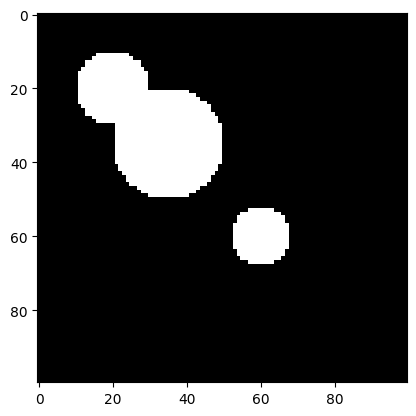

In [9]:
c: Canvas = Canvas(100, 100)
c.disk(20, 20, 10)
c.disk(35, 35, 15)
c.disk(60, 60, 8)
c.show()

## Dealing with Overlaps: Distance Maxima and Watershedding

We now aim to perform an instance segmentation of this image. In particular, a so-called segmentation mask has the same dimensions as the original image, with each pixel value being the id of the object it belongs to.
The value 0 is reserved for the background.
In our case, 3 more values are to be assigned, 1, 2, and 3, corresponding to the 3 circle instances.

We solve this problem via a commonly used approach:
1. Generate a distance field to the background. The background is black and has value 0. Based on this, we assign each pixel a distance to the background.
2. Let the local maxima correspond to the centers of the objects.
3. Use the [Watershed algorithm](https://en.wikipedia.org/wiki/Watershed_(image_processing)) to assign the remaining pixels.

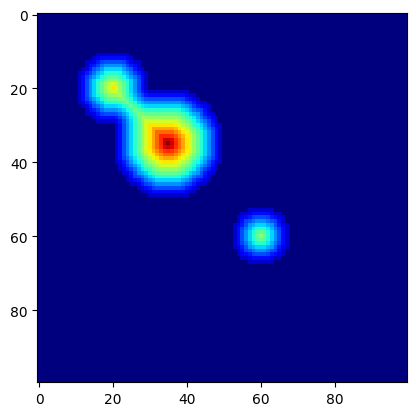

In [10]:
from scipy import ndimage as ndi

# Compute distance to 0-valued background
distance: np.ndarray = ndi.distance_transform_edt(c.img)
assert isinstance(distance, np.ndarray), "ensure type"

# Show the distance field as a heatmap
plt.imshow(distance, cmap=plt.cm.jet);

We next use `peak_local_max(...)` to find local maxima. The function has a parameter that specifies the locality: `footprint (ndarray of bools)` that is a mask for the local region within which to search for peaks at every point in `image`.

Number of cells: 3


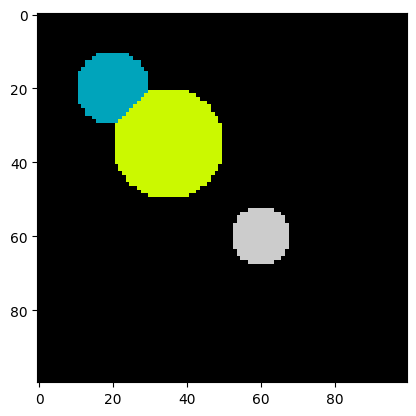

In [11]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max


def find_watershed(
        img: np.ndarray,
        min_distance: int=10,
        footprint: np.ndarray=np.ones((10,10))
    ) -> tuple[np.ndarray, int]:
    """Find watershed segmentation of an image.
    
    Arguments:
        img: input image (2D array)
        min_distance: minimum distance between local maxima
        footprint: search area for local maxima
    
    Returns:
        labels: segmentation labels of pixels
        num_features: number of detected features
    """
    
    # Compute distance to background (background has value 0)
    distance: np.ndarray = ndi.distance_transform_edt(img)
    assert isinstance(distance, np.ndarray), "ensure type"

    # Get local (within footprint) maxima of the distance field
    # filter via minimum distance between maxima
    coords = peak_local_max(distance, labels=img, min_distance=min_distance, footprint=footprint)

    # Create segmentation labels for pixels
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, num_features = ndi.label(mask)
    return watershed(-distance, markers, mask=img), num_features

labels, num_features = find_watershed(c.img)
plt.imshow(labels, cmap=plt.cm.nipy_spectral)
print("Number of cells:", num_features)

## Noise

Let's increase the difficulty by adding some noise.
Clearly the type of noise depends on the microscopy setup.
Cell debris, inhomogeneous illumination, and dist on the lense or the measurement setup are only a few examples.
For the sake of simplicity, we add random pixels as an idealized noise source.

The function `np.random.random(shape)` returns random floats of shape `shape`, with each pixel being uniformly random in $[0, 1)$.

By multiplying a random value for a pixel by a constant $c$ (here, 1.1) and casting it to an `int`, we obtain that a pixel is `1` with probability $c - 1$ (here, 0.1) and `0`, otherwise.

Using this value as additive noise, we obtain:

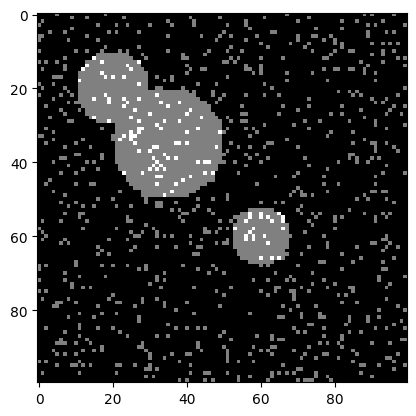

In [12]:
img = c.img + (1.1 * np.random.random(c.img.shape)).astype("int64")
plt.imshow(img, cmap=plt.cm.gray);

Let us try the watershed algorithm directly on the noisy image.

Number of cells: 42


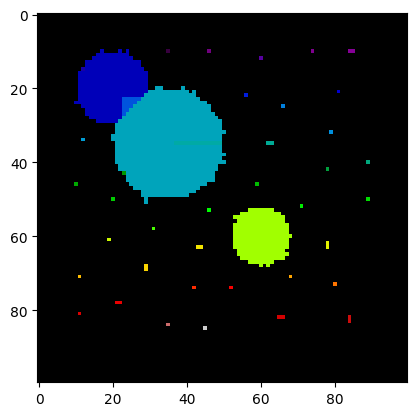

In [13]:
labels, num_features = find_watershed(img)
plt.imshow(labels, cmap=plt.cm.nipy_spectral)
print("Number of cells:", num_features)

The segmentation and the number of cells is clearly off.
All the single pixels are recognized as small cells.

We can do some image preprocessing to fix this.
One idea to remove small speckles is to erode them - letting the background grow into the object, and in a second step grow back the remaining objects.
The idea is that small speckles will be deleted in the first step, while large objects are almost not altered by the two consecutive steps.

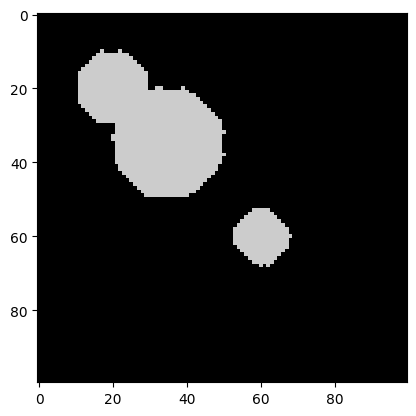

In [14]:
from scipy.ndimage import binary_erosion, binary_dilation

# shrink
img_new = binary_erosion(img, iterations=5)

# grow
img_new = binary_dilation(img_new, iterations=5)

plt.imshow(img_new, cmap=plt.cm.nipy_spectral);

It worked! All the speckles are gone. The objects have changed shape a bit, but this should not impede the watershed algorithm too much.

Let's try it on the preprocessed image.

Number of cells: 3


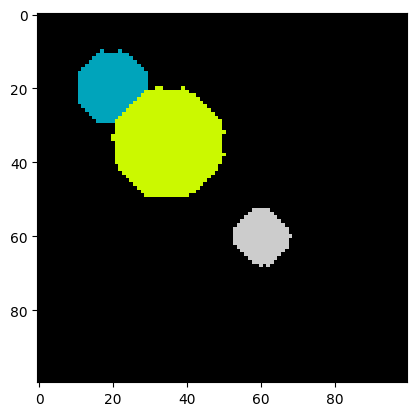

In [15]:
labels, num_features = find_watershed(img_new)
plt.imshow(labels, cmap=plt.cm.nipy_spectral)
print("Number of cells:", num_features)

Indeed, the segmentation is correct! We are ready for real data.

## Microscopic data of *E. coli*

We have uploaded an image of *E. coli* that we took in our lab with a microfluidic setup, an inverted microscope (40x lense), and a Raspberry Pi + camera.
The image `data/ecoli.png` is a crop of this image showing 3 bacteria.

The length of an *E. coli* is roughly 2 um, giving us a rough idea of the size of the crop as about 15 um x 15 um.

Since we do not expect any relevant information in the colors, we convert the image to gray-scale.

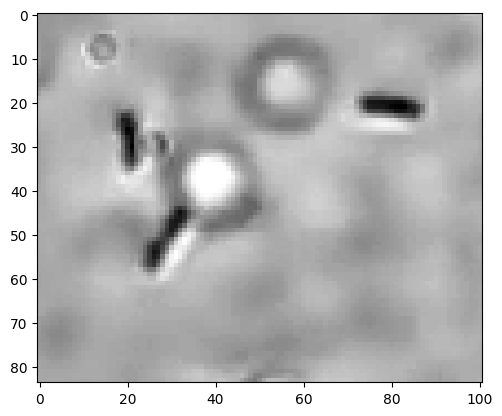

In [16]:
from skimage.color import rgb2gray

# Read image
img = skimage.io.imread("data/ecoli.png")

# Convert to grayscale
img = rgb2gray(img)

plt.imshow(img, cmap=plt.cm.gray);

We observe three _E. coli_ and one speckle that is either a small _E. coli_ or not further identified debris. For our purpose, we aim to not count this as a cell. The image also shows some circles that are unintended.

Following our previously successful procedure, let us threshold the image. After scaling pixel values to be within 0 and 255, we chose 180 as the object-background threshold. The choice was done by playing around with the threshold and observing the output.

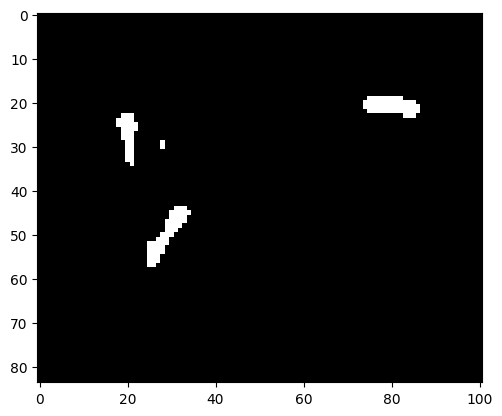

In [17]:
img_bin = np.zeros(img.shape).astype("int64")
mask = (img*255 < 180)
img_bin[mask] = 100
plt.imshow(img_bin, cmap=plt.cm.gray);

There is a small speckle observable that does not correspond to an *E. coli*. We can apply the erosion-dilation preprocessing that previously solved the problem with the pixel noise.

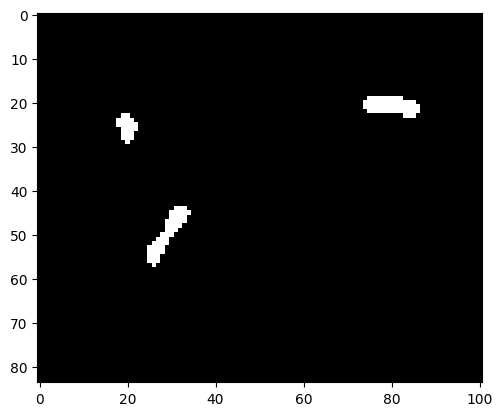

In [18]:
img_bin = binary_erosion(img_bin, iterations=1)
img_bin = binary_dilation(img_bin, iterations=1)

plt.imshow(img_bin, cmap=plt.cm.gray);

Indeed, the speckle is gone.

Number of cells: 3


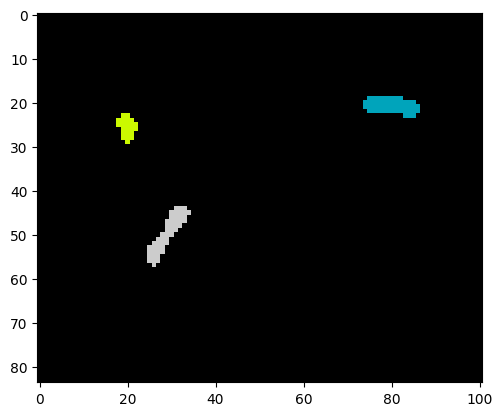

In [19]:
labels, num_features = find_watershed(img_bin, min_distance=10)
plt.imshow(labels, cmap=plt.cm.nipy_spectral)
print("Number of cells:", num_features)

As we see, a correct instance segmentation was obtained.

## Intersection over Union (IoU)

Given an available true segmentation of an object, we may define the following measures:
- $A_\text{intersection}$ as the size of the intersection area of the true and predicted object.
- $A_\text{union}$ as the size of the union area of the true and predicted object.

Then, IoU is defined as $A_\text{intersection} / A_\text{union}$.
The measure is between 0 and 1, with 1 signifying identity of predicted and true object.

<hr>
**License**: © 2025 Matthias Függer and Thomas Nowak. Licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).